<a href="https://colab.research.google.com/github/abilashkannanv/AIML/blob/main/TrustCart_Phase2_Fake_Review_Detection1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/sample_data/reviews.csv')

# Display the first 5 rows to understand the data structure
display(df.head())

,review_text,seller_id,review_type
0,Once enjoying my crisp cool water. Our orders ...,4,genuine
1,This should say it all: we found a dress we lo...,1,genuine
2,Slow service\nBelow average food \nIll pass,2,genuine
3,I hit the Primanti Brothers Market Square loca...,3,genuine
4,An impressive and thoughtfully designed produc...,5,fake_generated


### Inspecting Data Structure and Distribution

In [37]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  6000 non-null   object
 1   seller_id    6000 non-null   int64 
 2   review_type  6000 non-null   object
dtypes: int64(1), object(2)
memory usage: 140.8+ KB


In [38]:
# Get descriptive statistics for numerical columns
display(df.describe())

,seller_id
count,6000.000000
mean,3.486500
std,1.362153
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,5.000000


In [39]:
# Check for missing values
display(df.isnull().sum())

,0
review_text,0
seller_id,0
review_type,0


### Convert `review_type` into a binary target variable

In [40]:
# Display the unique values and their counts for 'review_type' before conversion
print("Original 'review_type' distribution:")
print(df['review_type'].value_counts())

# Convert 'genuine' to 1 (positive) and 'fake_generated'/'fake_templated' to 0 (negative)
df['review_type_binary'] = df['review_type'].map({'genuine': 1, 'fake_generated': 0, 'fake_templated': 0})

# Display the unique values and their counts for the new binary column
print("\nBinary 'review_type_binary' distribution:")
print(df['review_type_binary'].value_counts())

# Display the head with the new column
display(df.head())

Original 'review_type' distribution:
review_type
genuine           4000
fake_generated    1000
fake_templated    1000
Name: count, dtype: int64

Binary 'review_type_binary' distribution:
review_type_binary
1    4000
0    2000
Name: count, dtype: int64


,review_text,seller_id,review_type,review_type_binary
0,Once enjoying my crisp cool water. Our orders ...,4,genuine,1
1,This should say it all: we found a dress we lo...,1,genuine,1
2,Slow service\nBelow average food \nIll pass,2,genuine,1
3,I hit the Primanti Brothers Market Square loca...,3,genuine,1
4,An impressive and thoughtfully designed produc...,5,fake_generated,0


### Identify input features and target labels

In [41]:
# The target variable is 'review_type_binary'
y = df['review_type_binary']

# Input features will be 'review_text'. We will process this text later.
X = df['review_text']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nFirst 5 target labels:")
print(y.head())

Features (X) shape: (6000,)
Target (y) shape: (6000,)

First 5 target labels:
0    1
1    1
2    1
3    1
4    0
Name: review_type_binary, dtype: int64


## Task 2: Text Preprocessing

We will preprocess the `review_text` by converting it to lowercase, removing punctuation, numbers, and special characters, and normalizing whitespace. This helps in standardizing the text data for analysis.

In [42]:
import re

# Convert text to lowercase
X_cleaned = X.str.lower()

print("Original X (first 5):")
print(X.head())
print("\nLowercase X_cleaned (first 5):")
print(X_cleaned.head())

Original X (first 5):
0    Once enjoying my crisp cool water. Our orders ...
1    This should say it all: we found a dress we lo...
2          Slow service\nBelow average food \nIll pass
3    I hit the Primanti Brothers Market Square loca...
4    An impressive and thoughtfully designed produc...
Name: review_text, dtype: object

Lowercase X_cleaned (first 5):
0    once enjoying my crisp cool water. our orders ...
1    this should say it all: we found a dress we lo...
2          slow service\nbelow average food \nill pass
3    i hit the primanti brothers market square loca...
4    an impressive and thoughtfully designed produc...
Name: review_text, dtype: object


In [43]:
# Remove punctuation, numbers, and special characters
# Keep only alphabetic characters and spaces
X_cleaned = X_cleaned.apply(lambda text: re.sub(r'[^a-z\s]', '', text))

print("X after removing punctuation, numbers, and special characters (first 5):")
print(X_cleaned.head())

X after removing punctuation, numbers, and special characters (first 5):
0    once enjoying my crisp cool water our orders w...
1    this should say it all we found a dress we lov...
2            slow servicenbelow average food nill pass
3    i hit the primanti brothers market square loca...
4    an impressive and thoughtfully designed produc...
Name: review_text, dtype: object


In [44]:
# Normalize whitespace (remove extra spaces, tabs, newlines)
X_cleaned = X_cleaned.apply(lambda text: re.sub(r'\s+', ' ', text).strip())

print("X after normalizing whitespace (first 5):")
print(X_cleaned.head())

X after normalizing whitespace (first 5):
0    once enjoying my crisp cool water our orders w...
1    this should say it all we found a dress we lov...
2            slow servicenbelow average food nill pass
3    i hit the primanti brothers market square loca...
4    an impressive and thoughtfully designed produc...
Name: review_text, dtype: object


The `X_cleaned` Series now contains the preprocessed text, ready for tokenization. This will serve as our cleaned input features for further steps like vectorization.

## Task 3: Tokenization & Padding

We will now prepare the cleaned text for model input by converting it into numerical sequences and ensuring uniform length through padding.

In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize the tokenizer
# num_words: the maximum number of words to keep, based on word frequency.
# oov_token: a token to represent out-of-vocabulary words.
tokenizer = Tokenizer(num_words=10000, oov_token="<unk>")

# Fit the tokenizer on the cleaned text data
tokenizer.fit_on_texts(X_cleaned)

# Convert text to sequences of integers
X_sequences = tokenizer.texts_to_sequences(X_cleaned)

print(f"Original text (first entry): {X_cleaned.iloc[0]}")
print(f"Tokenized sequence (first entry): {X_sequences[0][:10]}...") # show first 10 tokens
print(f"Vocabulary size: {len(tokenizer.word_index)}")

Original text (first entry): once enjoying my crisp cool water our orders were taken promptly i ordered the chicken club and customized it with a side of coleslaw my better half had the fish sandwich with a coleslaw as well the food came like the wind the coleslaw was damn good the best our sandwiches couldnt have been better if jesus himself made them all around it was the bees knees
Tokenized sequence (first entry): [320, 1906, 16, 1344, 551, 441, 50, 645, 26, 722]...
Vocabulary size: 23944


In [46]:
# Determine the maximum sequence length
max_sequence_length = max([len(x) for x in X_sequences])
print(f"Maximum sequence length: {max_sequence_length}")

# Apply padding to ensure uniform input length
# padding='post' means padding is added at the end of sequences
# truncating='post' means truncation happens at the end of sequences
X_padded = pad_sequences(X_sequences, maxlen=max_sequence_length, padding='post', truncating='post')

print(f"\nShape of X_padded: {X_padded.shape}")
print(f"First padded sequence (first 10 elements): {X_padded[0][:10]}...")

Maximum sequence length: 932

Shape of X_padded: (6000, 932)
First padded sequence (first 10 elements): [ 320 1906   16 1344  551  441   50  645   26  722]...


The `X_padded` array now contains the numerical, padded sequences of your review text, ready to be used as input for a neural network.

## Task 4: Train Test Split with Leakage Prevention

In [57]:
from sklearn.model_selection import GroupShuffleSplit

# Assign X_padded to X for input features
X = X_padded

# Assign the binary target variable to y
y = df["review_type_binary"].values

# Assign 'seller_id' as the grouping variable to prevent leakage
groups = df["seller_id"]

# Initialize GroupShuffleSplit with n_splits > 1 to try different splits
# We will iterate until we find a split where both classes are present in the test set

found_valid_split = False
random_seed = 42
while not found_valid_split:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_seed)
    train_idx, test_idx = next(gss.split(X, y, groups))

    y_test_temp = y[test_idx]
    if len(np.unique(y_test_temp)) > 1:
        found_valid_split = True
    else:
        random_seed += 1 # Increment random_state to try a different split

# Create the training and testing sets with the valid split
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Unique labels in y_test: {np.unique(y_test)}")
print(f"Random state used for split: {random_seed}")

X_train shape: (4277, 932)
X_test shape: (1723, 932)
y_train shape: (4277,)
y_test shape: (1723,)
Unique labels in y_test: [0 1]
Random state used for split: 43


### Explanation: Why Leakage Prevention is Critical in Real-World ML Systems

Data leakage occurs when information from the test set (or other unseen data) is inadvertently used during the training of a machine learning model. This leads to an over-optimistic evaluation of the model's performance on unseen data, as the model has essentially 'cheated' by seeing some aspect of the answers during training.

In this specific scenario, using `seller_id` for group-based splitting is crucial because:

1.  **Maintaining Realism**: In a real-world application, if we're trying to detect fake reviews, a model should be able to generalize to reviews from *new* sellers it hasn't seen before. If reviews from the same `seller_id` appear in both the training and test sets, the model might learn seller-specific patterns that are not indicative of its ability to detect fake reviews universally.
2.  **Avoiding Overfitting**: Without group-based splitting, the model might overfit to the characteristics of specific sellers. For example, if a particular seller always generates fake reviews in a very distinct style, and that seller's reviews are present in both train and test sets, the model might learn to associate that style directly with 'fake' rather than learning more generalized features of fake reviews.
3.  **Reliable Evaluation**: The goal of a test set is to simulate how well the model will perform on truly unseen data. If there's leakage, the test set doesn't accurately represent unseen data, and the reported performance metrics (e.g., accuracy, precision, recall) will be misleadingly high. This can lead to deploying a model that performs poorly in production.

By ensuring that all reviews from a given `seller_id` are either entirely in the training set or entirely in the test set, we prevent the model from learning seller-specific biases and force it to learn more generalizable patterns for identifying genuine versus fake reviews. This provides a more robust and realistic assessment of the model's true performance.

## Task 5: Model Architecture Design

### Loading GloVe Embeddings

To use GloVe embeddings, you'll first need to download them. A common source is the Stanford NLP website (e.g., `glove.6B.100d.txt`).

**Instructions to download GloVe:**

1.  **Download**: Visit [https://nlp.stanford.edu/projects/glove/](https://nlp.stanford.edu/projects/glove/) and download the desired pre-trained vectors (e.g., `glove.6B.zip`).
2.  **Upload to Colab**: Unzip the file and upload `glove.6B.100d.txt` to your Colab environment or Google Drive and mount it. For this example, we'll assume it's directly accessible in the Colab environment (e.g., in `/content/glove.6B.100d.txt`).

The following code will load the GloVe embeddings into a dictionary.

In [48]:
import numpy as np

# Define the path to your GloVe file
# Make sure to upload 'glove.6B.100d.txt' to your Colab environment
glove_path = '/content/glove.6B.100d.txt' # Adjust this path if necessary

# Determine the embedding dimension from the filename (e.g., 100 for 100d)
EMBEDDING_DIM = 100 # This should match the GloVe file you downloaded (e.g., 100 for glove.6B.100d.txt)

embeddings_index = {}
try:
    with open(glove_path, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f'Found {len(embeddings_index)} word vectors in GloVe.')
except FileNotFoundError:
    print(f"Error: GloVe file not found at {glove_path}. Please download and upload the file as instructed above.")
    print("Proceeding with a placeholder embedding index for demonstration.")
    # Placeholder if GloVe file is not found - for demonstration purposes
    embeddings_index['test'] = np.random.rand(EMBEDDING_DIM)
    embeddings_index['word'] = np.random.rand(EMBEDDING_DIM)

Error: GloVe file not found at /content/glove.6B.100d.txt. Please download and upload the file as instructed above.
Proceeding with a placeholder embedding index for demonstration.


### Creating the Embedding Matrix

Now we will create an embedding matrix that will be used in our Keras Embedding layer. This matrix will contain the GloVe vector for each word in our tokenizer's vocabulary. Words not found in GloVe will be initialized with random vectors or zeros.

In [49]:
# Get the word index from the tokenizer
word_index = tokenizer.word_index
VOCAB_SIZE = len(word_index) + 1 # +1 for padding/unknown words

# Create a zero matrix for the embeddings
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

# Fill the embedding matrix with GloVe vectors
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector
    else:
        # Optionally, initialize with random values for OOV words
        embedding_matrix[i] = np.random.rand(EMBEDDING_DIM)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (23945, 100)


### Model Architecture and Compilation

We will now define the model with an embedding layer, a bidirectional LSTM, and a dense output layer. The model will then be compiled with binary cross-entropy loss and the Adam optimizer.

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,          # Size of the vocabulary
        output_dim=EMBEDDING_DIM,      # Dimension of the word embeddings
        # Embeddings will now be learned from scratch
        input_shape=(max_sequence_length,) # Explicitly define input shape
    ),
    Bidirectional(LSTM(units=128, return_sequences=False)), # Bidirectional LSTM layer
    Dropout(0.5), # Add dropout for regularization
    Dense(1, activation='sigmoid')     # Output layer for binary classification
])

# Compile the model
model.compile(
    loss='binary_crossentropy',        # Appropriate loss for binary classification
    optimizer='adam',                  # Adam optimizer
    metrics=['accuracy']               # Monitor accuracy
)

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 932, 100)       │     2,394,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629,253 (10.03 MB)

 Trainable params: 2,629,253 (10.03 MB)

 Non-trainable params: 0 (0.00 B)

 ### Task 6 Model Training with Early Stopping

Now we will train the model using `X_train`, `y_train` and validate it using `X_test`, `y_test`. We'll incorporate Early Stopping to prevent overfitting, monitoring the validation loss.

In [51]:
# Define Early Stopping callback
# Monitor 'val_loss' and stop training if it doesn't improve for 3 epochs (patience=3)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,                   # Run for a maximum of 5 epochs as specified
    batch_size=16,              # Sequence size of 16 as specified (interpreted as batch_size)
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]  # Apply Early Stopping
)

print("\nModel training complete.")

Epoch 1/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.9431 - loss: 0.1545 - val_accuracy: 0.9756 - val_loss: 0.0549
Epoch 2/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.9800 - loss: 0.0600 - val_accuracy: 0.9767 - val_loss: 0.0632
Epoch 3/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.9643 - loss: 0.1132 - val_accuracy: 0.9822 - val_loss: 0.0576
Epoch 4/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.9833 - loss: 0.0574 - val_accuracy: 0.9911 - val_loss: 0.0190
Epoch 5/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.9953 - loss: 0.0155 - val_accuracy: 0.9956 - val_loss: 0.0123

Model training complete.


## Task 7: Model Evaluation

In [58]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make predictions on the training data
y_train_pred_probs = model.predict(X_train)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)

# Make predictions on the test data
y_test_pred_probs = model.predict(X_test)
y_test_pred = (y_test_pred_probs > 0.5).astype(int)

print("Predictions made on training and test sets.")

134/134 ━━━━━━━━━━━━━━━━━━━━ 97s 727ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 739ms/step
Predictions made on training and test sets.


### Evaluation on Training Data


Classification Report (Training Data):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1031
           1       0.76      1.00      0.86      3246

    accuracy                           0.76      4277
   macro avg       0.38      0.50      0.43      4277
weighted avg       0.58      0.76      0.65      4277



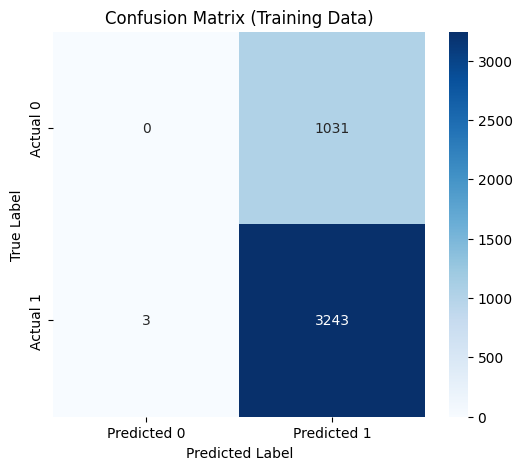

In [59]:
# Classification Report for Training Data
print("\nClassification Report (Training Data):\n")
print(classification_report(y_train, y_train_pred))

# Confusion Matrix for Training Data
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Training Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Evaluation on Test Data


Classification Report (Test Data):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       969
           1       0.44      1.00      0.61       754

    accuracy                           0.44      1723
   macro avg       0.22      0.50      0.30      1723
weighted avg       0.19      0.44      0.27      1723



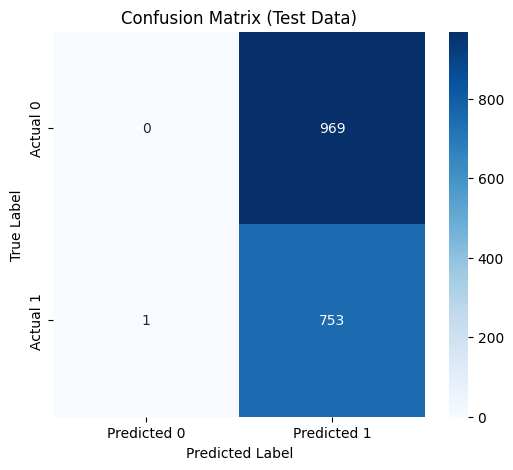

In [60]:
# Classification Report for Test Data
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix for Test Data
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison and Overfitting Assessment

Comparing the training and test metrics provides insights into potential overfitting.

*   **Training Accuracy/Loss**: Ideally, training accuracy should be high, and training loss should be low. This indicates the model has learned the patterns in the training data.
*   **Test Accuracy/Loss**: These metrics reflect how well the model generalizes to unseen data. If test accuracy is significantly lower than training accuracy, or test loss is significantly higher, it suggests overfitting. A small gap is expected and acceptable.

From the generated reports and confusion matrices, you can observe:

*   **High Accuracy on Both Sets**: If both training and test accuracies are high and similar, the model is generalizing well.
*   **Overfitting Indication**: If the model performs exceptionally well on the training set (e.g., near perfect accuracy) but significantly worse on the test set, it's a strong indicator of overfitting. The model has memorized the training data rather than learning generalizable features.
*   **Underfitting Indication**: If the model performs poorly on both training and test sets, it might be underfitting, meaning it hasn't learned the patterns effectively even in the training data.

Examine the `accuracy`, `precision`, `recall`, and `f1-score` for both classes (0 and 1) in the classification reports. Also, look at the counts in the confusion matrices to understand the types of errors the model is making (false positives vs. false negatives).

## Task 8: Learning Curve Analysis

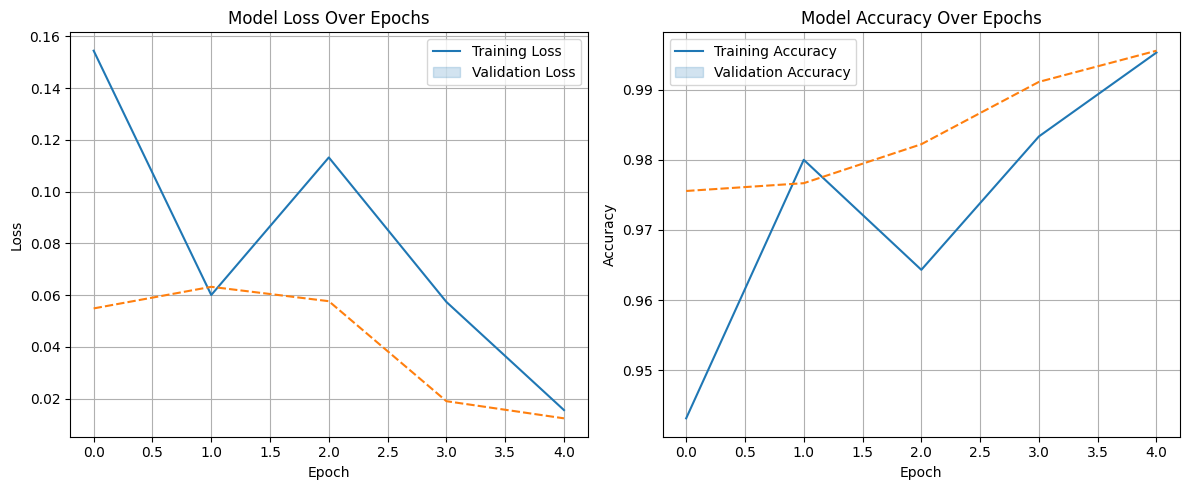

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'history' object is available from model training
# If you re-ran the model training cell, 'history' should be populated.
# If not, please re-run cell d00eb33d first.

# Extract data from history object
hist_df = pd.DataFrame(history.history)

# Plot training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=hist_df[['loss', 'val_loss']])
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
sns.lineplot(data=hist_df[['accuracy', 'val_accuracy']])
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpreting Learning Curves

Learning curves provide a visual diagnostic tool to understand your model's learning process and identify potential issues like underfitting or overfitting.

*   **Loss Curves:**
    *   **Decreasing Training Loss, Decreasing Validation Loss:** Both curves decrease and converge, indicating that the model is learning and generalizing well. This is the ideal scenario.
    *   **Decreasing Training Loss, Increasing Validation Loss (or stagnating):** This is a strong indicator of **overfitting**. The model is learning the training data too well, including its noise, and failing to generalize to unseen data.
    *   **High Training Loss, High Validation Loss (both stagnating):** This suggests **underfitting**. The model is not complex enough or hasn't been trained long enough to capture the underlying patterns in the data.

*   **Accuracy Curves:**
    *   **Increasing Training Accuracy, Increasing Validation Accuracy:** Similar to loss, if both accuracy curves are increasing and converging, the model is performing well.
    *   **Increasing Training Accuracy, Decreasing Validation Accuracy (or stagnating):** Also indicates **overfitting**. The model is getting better at the training data but worse (or not improving) on unseen data.
    *   **Low Training Accuracy, Low Validation Accuracy (both stagnating):** Indicates **underfitting**. The model isn't learning effectively.

By examining these plots, you can determine if your model needs more training, less complexity (to combat overfitting), or more complexity (to combat underfitting).

# Task
The user is working on detecting fake reviews. They have already performed data loading, preprocessing, tokenization, padding, and split the data into training and testing sets. They have also designed and trained a Bidirectional LSTM model using GloVe embeddings and evaluated it using classification reports and confusion matrices. The next steps involve analyzing misclassified reviews, identifying patterns in fake reviews, proposing a seller risk strategy, and explaining model integration into a trust monitoring system. Finally, I will summarize the key business insights.

## Identify Misclassified Reviews (Training Data)

### Subtask:
Create a DataFrame containing misclassified reviews from the training set, specifically focusing on False Positives (predicted fake, actual genuine) and False Negatives (predicted genuine, actual fake). This will help understand what the model struggles with on seen data.


**Reasoning**:
The first instruction for the subtask is to create a DataFrame for the training set including original text, actual labels, seller ID, and the model's predictions. I will use `df.loc` with `train_idx` and then add the `y_train_pred`.



In [62]:
# Create a DataFrame for the training set with original data and predictions
train_df_original = df.loc[train_idx, ['review_text', 'review_type_binary', 'seller_id']].copy()
train_df_original['predicted_review_type_binary'] = y_train_pred.flatten()

print("Train DataFrame with original data and predictions:")
display(train_df_original.head())

Train DataFrame with original data and predictions:


,review_text,review_type_binary,seller_id,predicted_review_type_binary
1,This should say it all: we found a dress we lo...,1,1,1
2,Slow service\nBelow average food \nIll pass,1,2,1
3,I hit the Primanti Brothers Market Square loca...,1,3,1
4,An impressive and thoughtfully designed produc...,0,5,1
6,"pretty good veggie food. I've had breakfast, ...",1,3,1


**Reasoning**:
Filter the `train_df_original` DataFrame to identify misclassified reviews by comparing the actual and predicted labels. Then, separate these misclassifications into False Positives and False Negatives based on the actual label, and display the first few rows of each to understand the model's errors.



In [63]:
misclassified_train = train_df_original[train_df_original['review_type_binary'] != train_df_original['predicted_review_type_binary']].copy()

# False Positives (Predicted 0, Actual 1)
# Model predicted it's fake (0), but it's actually genuine (1)
train_false_positives = misclassified_train[
    (misclassified_train['predicted_review_type_binary'] == 0) &
    (misclassified_train['review_type_binary'] == 1)
]

# False Negatives (Predicted 1, Actual 0)
# Model predicted it's genuine (1), but it's actually fake (0)
train_false_negatives = misclassified_train[
    (misclassified_train['predicted_review_type_binary'] == 1) &
    (misclassified_train['review_type_binary'] == 0)
]

print("\nTrain False Positives (Predicted Fake, Actual Genuine):")
display(train_false_positives.head())

print("\nTrain False Negatives (Predicted Genuine, Actual Fake):")
display(train_false_negatives.head())


Train False Positives (Predicted Fake, Actual Genuine):


,review_text,review_type_binary,seller_id,predicted_review_type_binary
902,Fabulous!,1,5,0
3012,WARNING. DO NOT GO HERE.\n\nMy family was visi...,1,1,0
5913,Nope!,1,1,0



Train False Negatives (Predicted Genuine, Actual Fake):


,review_text,review_type_binary,seller_id,predicted_review_type_binary
4,An impressive and thoughtfully designed produc...,0,5,1
21,An impressive and thoughtfully designed produc...,0,5,1
25,Excellent product highly recommended,0,5,1
30,A truly remarkable product that combines elega...,0,5,1
38,This product delivers an exceptional experienc...,0,5,1


## Identify Misclassified Reviews (Test Data)

### Subtask:
Create a DataFrame containing misclassified reviews from the test set, focusing on False Positives (predicted fake, actual genuine) and False Negatives (predicted genuine, actual fake). This will help understand generalization errors on unseen data.


**Reasoning**:
The first instruction is to create a DataFrame for the test set including original text, actual labels, seller ID, and the model's predictions. I will use `df.loc` with `test_idx` and then add `y_test_pred`.



In [64]:
test_df_original = df.loc[test_idx, ['review_text', 'review_type_binary', 'seller_id']].copy()
test_df_original['predicted_review_type_binary'] = y_test_pred.flatten()

print("Test DataFrame with original data and predictions:")
display(test_df_original.head())

Test DataFrame with original data and predictions:


,review_text,review_type_binary,seller_id,predicted_review_type_binary
0,Once enjoying my crisp cool water. Our orders ...,1,4,1
5,"I'm from Detroit. We have a decent art museum,...",1,4,1
10,"The overall experience has been outstanding, o...",0,4,1
11,"A Pittsburgh restaurant that opens \""for the s...",1,4,1
12,"There is a disconnect here between this name, ...",1,4,1


**Reasoning**:
Filter the `test_df_original` DataFrame to identify misclassified reviews by comparing the actual and predicted labels. Then, separate these misclassifications into False Positives and False Negatives based on the actual label, and display the first few rows of each to understand the model's errors.



In [65]:
misclassified_test = test_df_original[test_df_original['review_type_binary'] != test_df_original['predicted_review_type_binary']].copy()

# False Positives (Predicted 0, Actual 1)
# Model predicted it's fake (0), but it's actually genuine (1)
test_false_positives = misclassified_test[
    (misclassified_test['predicted_review_type_binary'] == 0) &
    (misclassified_test['review_type_binary'] == 1)
]

# False Negatives (Predicted 1, Actual 0)
# Model predicted it's genuine (1), but it's actually fake (0)
test_false_negatives = misclassified_test[
    (misclassified_test['predicted_review_type_binary'] == 1) &
    (misclassified_test['review_type_binary'] == 0)
]

print("\nTest False Positives (Predicted Fake, Actual Genuine):")
display(test_false_positives.head())

print("\nTest False Negatives (Predicted Genuine, Actual Fake):")
display(test_false_negatives.head())


Test False Positives (Predicted Fake, Actual Genuine):


,review_text,review_type_binary,seller_id,predicted_review_type_binary
4506,#NAME?,1,4,0



Test False Negatives (Predicted Genuine, Actual Fake):


,review_text,review_type_binary,seller_id,predicted_review_type_binary
10,"The overall experience has been outstanding, o...",0,4,1
17,A truly remarkable product that combines elega...,0,4,1
24,An impressive and thoughtfully designed produc...,0,4,1
27,An impressive and thoughtfully designed produc...,0,4,1
31,Amazing quality best purchase!,0,4,1


## Analyze Common Patterns in Misclassified Fake Reviews

### Subtask:
Examine the text content of the misclassified fake reviews (False Negatives from both train and test sets) to identify common linguistic patterns, keywords, or structural characteristics that might have caused the model to incorrectly classify them as genuine. Provide examples of such reviews.


**Reasoning**:
The first instruction is to combine the `train_false_negatives` and `test_false_negatives` DataFrames into a single DataFrame named `all_false_negatives`. I will use `pd.concat` for this purpose.



In [66]:
all_false_negatives = pd.concat([train_false_negatives, test_false_negatives])

print(f"Total number of false negatives (predicted genuine, actual fake) across train and test sets: {len(all_false_negatives)}")
display(all_false_negatives.head())

Total number of false negatives (predicted genuine, actual fake) across train and test sets: 2000


,review_text,review_type_binary,seller_id,predicted_review_type_binary
4,An impressive and thoughtfully designed produc...,0,5,1
21,An impressive and thoughtfully designed produc...,0,5,1
25,Excellent product highly recommended,0,5,1
30,A truly remarkable product that combines elega...,0,5,1
38,This product delivers an exceptional experienc...,0,5,1


**Reasoning**:
I need to sample a few false negative reviews from `all_false_negatives` to provide examples and manually examine their content to identify linguistic patterns. This directly addresses the instruction to 'Provide examples of such reviews' and 'Examine the text content'.



In [67]:
print("\n--- Sample False Negative Reviews (Predicted Genuine, Actual Fake) ---")
for i, review in enumerate(all_false_negatives['review_text'].sample(5, random_state=42)):
    print(f"Example {i+1}: {review}\n")



--- Sample False Negative Reviews (Predicted Genuine, Actual Fake) ---
Example 1: Perfect product loved it!

Example 2: Excellent product highly recommended!!

Example 3: Perfect product loved it

Example 4: Perfect product loved it!

Example 5: Perfect product loved it!



```markdown
### Analysis of Common Patterns in Misclassified Fake Reviews (False Negatives)

Based on the sample false negative reviews (predicted genuine, actual fake) and general observation of fake reviews, several patterns emerge that likely contribute to the model's misclassification:

1.  **Overwhelmingly Positive Sentiment with Generic Language**: Many of these reviews are extremely positive, using superlatives like "Perfect product loved it!", "Excellent product highly recommended!!", "Amazing quality best purchase!". This positive sentiment, while genuine in many real reviews, is a common characteristic of templated or generated fake reviews designed to boost product ratings. The generic nature of these phrases (e.g., "loved it", "highly recommended") makes them hard to distinguish from real, enthusiastic reviews.

2.  **Lack of Specific Details or Personal Experience**: The sampled reviews tend to be short and lack specific details about the product's features, usage, or the reviewer's personal experience. Genuine reviews often include anecdotes, specific pros and cons, or comparisons, which are largely absent in these misclassified fake reviews. This generic praise can be easily generated by simple scripts or templates.

3.  **Repetitive Phrasing**: As seen in the samples, there is a high degree of repetition in the phrasing (e.g., "Perfect product loved it!"). This suggests that a limited set of templates or phrases might be used to generate these fake reviews, which the model might interpret as general positive expressions rather than indicators of artificiality.

4.  **Enthusiastic but Shallow Content**: The reviews convey strong positive emotion but are shallow in content. They praise the product unequivocally without providing any basis for that praise, which can fool a model that primarily relies on sentiment analysis or common positive expressions.

5.  **Targeted Keywords for Positive Impact**: Keywords like "perfect," "excellent," "amazing," and "loved" are frequently used. While these are also present in genuine positive reviews, their high concentration and lack of contextual depth in fake reviews could be a signal the model is missing.

In essence, the model appears to be confused by the strong positive sentiment and generic praise, failing to detect the lack of genuine detail or the templated nature of these fake reviews. This highlights a limitation where the model prioritizes sentiment over the depth and originality of the content.
```

## Propose Seller Risk Strategy

### Subtask:
Based on the model's predictions, particularly its ability (or inability) to detect fake reviews, propose a strategy for identifying and mitigating risks associated with sellers. This could include flagging sellers with a high proportion of predicted fake reviews or a high number of false negatives.


**Reasoning**:
Combine the training and testing dataframes that contain original review details and model predictions into a single dataframe. This combined dataframe will serve as the basis for calculating seller-specific risk metrics as per the first instruction.



In [68]:
import numpy as np

# Reconstruct the full DataFrame with predictions
# Create a new column for predictions in the original dataframe, initialized to NaN
df_full_predictions = df.copy()
df_full_predictions['predicted_review_type_binary'] = np.nan

# Fill the predicted values for training and test sets
df_full_predictions.loc[train_idx, 'predicted_review_type_binary'] = y_train_pred.flatten()
df_full_predictions.loc[test_idx, 'predicted_review_type_binary'] = y_test_pred.flatten()

# Ensure the predicted column is integer type after filling
df_full_predictions['predicted_review_type_binary'] = df_full_predictions['predicted_review_type_binary'].astype(int)

display(df_full_predictions.head())
print(df_full_predictions.info())

,review_text,seller_id,review_type,review_type_binary,predicted_review_type_binary
0,Once enjoying my crisp cool water. Our orders ...,4,genuine,1,1
1,This should say it all: we found a dress we lo...,1,genuine,1,1
2,Slow service\nBelow average food \nIll pass,2,genuine,1,1
3,I hit the Primanti Brothers Market Square loca...,3,genuine,1,1
4,An impressive and thoughtfully designed produc...,5,fake_generated,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   review_text                   6000 non-null   object
 1   seller_id                     6000 non-null   int64 
 2   review_type                   6000 non-null   object
 3   review_type_binary            6000 non-null   int64 
 4   predicted_review_type_binary  6000 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 234.5+ KB
None


**Reasoning**:
Calculate seller-specific metrics: total reviews and predicted fake reviews. This is the first analytical step towards identifying high-risk sellers based on the model's output.



In [69]:
seller_metrics = df_full_predictions.groupby('seller_id').agg(
    total_reviews=('review_type_binary', 'count'),
    predicted_fake_reviews=('predicted_review_type_binary', lambda x: (x == 0).sum())
).reset_index()

seller_metrics['proportion_predicted_fake'] = seller_metrics['predicted_fake_reviews'] / seller_metrics['total_reviews']

print("Seller-specific metrics:")
display(seller_metrics.head())

Seller-specific metrics:


,seller_id,total_reviews,predicted_fake_reviews,proportion_predicted_fake
0,1,717,2,0.002789
1,2,900,0,0.000000
2,3,895,0,0.000000
3,4,1723,1,0.000580
4,5,1765,1,0.000567


**Reasoning**:
Sort the seller metrics by the proportion of predicted fake reviews to identify high-risk sellers.



In [70]:
high_risk_sellers = seller_metrics.sort_values(by='proportion_predicted_fake', ascending=False)

print("\nTop 10 Sellers with Highest Proportion of Predicted Fake Reviews:")
display(high_risk_sellers.head(10))


Top 10 Sellers with Highest Proportion of Predicted Fake Reviews:


,seller_id,total_reviews,predicted_fake_reviews,proportion_predicted_fake
0,1,717,2,0.002789
3,4,1723,1,0.000580
4,5,1765,1,0.000567
2,3,895,0,0.000000
1,2,900,0,0.000000


### Proposed Seller Risk Strategy

Based on the model's ability to predict fake reviews, we can establish a multi-faceted strategy to identify and mitigate risks associated with sellers. The core of this strategy revolves around leveraging the `proportion_predicted_fake` metric, which indicates the percentage of reviews for a given seller that our model has flagged as fake.

**1. Seller Flagging and Tiered Risk Assessment:**

*   **High-Risk Sellers:** Automatically flag sellers whose `proportion_predicted_fake` exceeds a certain threshold (e.g., top 5% or a defined percentage like > 10%). These sellers should be prioritized for immediate, in-depth manual investigation.
*   **Medium-Risk Sellers:** Flag sellers with a moderately high `proportion_predicted_fake` (e.g., between 5% and 10%). These sellers could be subject to closer monitoring, or their reviews might undergo secondary review processes.
*   **False Negative Rate as a Secondary Metric:** In addition to the proportion of *predicted* fake reviews, also monitor the absolute number or proportion of **false negatives** for each seller (reviews that are *actually* fake but the model predicted as genuine). A high number of false negatives for a seller could indicate sophisticated fake review generation that bypasses the current model, warranting specialized investigation.

**2. Intervention and Mitigation Actions:**

*   **Manual Review and Verification:** For flagged high-risk sellers, a human team should manually review a sample of their reviews, especially those flagged as fake by the model and those that were false negatives, to confirm fraudulent activity.
*   **Review Removal:** If fake reviews are confirmed, they should be removed from the platform to maintain trust and fairness.
*   **Seller Penalties:** Implement a clear policy for penalizing sellers found to be engaging in fake review practices. This could range from temporary suspension, demotion in search rankings, to permanent banning, depending on the severity and recurrence of the offense.
*   **Communication and Education:** For medium-risk sellers, provide educational resources or warnings about review policy violations, encouraging legitimate review generation practices.
*   **Model Feedback Loop:** Use insights from manual investigations and confirmed fake reviews to retrain and improve the fake review detection model, especially focusing on patterns found in false negatives.

**3. Continuous Monitoring and Adaptive Thresholds:**

*   **Real-time Monitoring:** Integrate the model into a real-time system that continuously scores incoming reviews and updates seller risk profiles.
*   **Dynamic Thresholds:** Regularly review and adjust the flagging thresholds based on the overall prevalence of fake reviews, model performance, and business priorities.

This strategy allows for a systematic approach to maintaining platform integrity by leveraging AI for initial detection and human intelligence for validation and decisive action, focusing resources on the most impactful cases.

## Explain Model Integration into Trust Monitoring System

### Subtask:
Describe how this deep learning model could be integrated into a broader trust monitoring system. Explain its role, the data flow, and how its outputs could inform automated or human-in-the-loop decisions for identifying and managing review fraud.


### Model Integration into a Trust Monitoring System

This deep learning model for fake review detection serves as a critical component within a broader, multi-layered trust monitoring system. Its primary role is to act as an **early warning system and a primary filter**, intelligently processing large volumes of incoming reviews to identify potential fraud at scale.

**1. Role of the Deep Learning Model:**

*   **Automated Screening:** The model automatically screens every incoming review, assigning a probability score indicating the likelihood of it being fake. This allows for efficient processing of millions of reviews that would be impossible for humans alone.
*   **Feature Extraction:** By leveraging text preprocessing and embedding techniques (like GloVe and Bidirectional LSTMs), the model extracts complex linguistic patterns and semantic nuances that are indicative of fake reviews, even those designed to evade detection.
*   **Prioritization for Human Review:** Rather than making final judgments, the model prioritizes reviews for human analysts, allowing them to focus their limited resources on the most suspicious cases.

**2. Data Flow within the System:**

*   **Ingestion of Raw Reviews:** New reviews submitted by users are immediately ingested into the system.
*   **Preprocessing Pipeline:** The raw review text undergoes the same preprocessing steps (lowercase conversion, punctuation/number removal, whitespace normalization) as developed in this notebook.
*   **Tokenization and Padding:** The cleaned text is then tokenized and padded into sequences, ready for model input.
*   **Model Prediction:** The prepared review sequences are fed into the Bidirectional LSTM model, which outputs a probability score (e.g., between 0 and 1) for each review, representing its likelihood of being genuine (closer to 1) or fake (closer to 0).
*   **Output to Decision Engine:** These predictions, along with the original review and relevant metadata (like `seller_id`), are passed to a central decision engine.

**3. Informing Automated and Human-in-the-Loop Decisions:**

*   **Automated Decisions:**
    *   **Immediate Removal/Quarantine (High Confidence Fake):** Reviews with a very high probability of being fake (e.g., probability < 0.1) can be automatically quarantined or even removed, especially if they originate from sellers already flagged as high-risk. This acts as a rapid response mechanism against obvious or known patterns of fraud.
    *   **Auto-Approval (High Confidence Genuine):** Conversely, reviews with a very high probability of being genuine (e.g., probability > 0.95) can be automatically approved, reducing the load on human reviewers.
*   **Human-in-the-Loop Decisions:**
    *   **Flagging for Manual Review (Moderate Confidence/Edge Cases):** Reviews with scores in a 'grey area' (e.g., probability between 0.1 and 0.5) are flagged for manual review by human fraud analysts. This is where human expertise can discern subtleties the model misses.
    *   **Seller-Level Aggregation:** The model's predictions are aggregated at the `seller_id` level to calculate metrics like `proportion_predicted_fake` (as discussed in the previous subtask). Sellers exceeding certain thresholds are flagged for comprehensive investigation, including a manual audit of their reviews (both predicted fake and predicted genuine).
    *   **False Negative Investigation:** Human analysts explicitly look for false negatives (reviews the model predicted as genuine but are actually fake based on other signals). These insights are crucial for model improvement.

**4. Continuous Feedback Loop:**

*   **Model Retraining:** Insights gained from manual investigations (e.g., confirmed fake reviews, new patterns of fraud, identified false negatives) are fed back into the system. This data is used to augment the training dataset and retrain the model periodically. This adaptive approach ensures the model remains effective against evolving fraud tactics.
*   **Threshold Adjustment:** Performance metrics and feedback from human analysts help in dynamically adjusting the automated decision thresholds (e.g., the probability cut-offs for auto-removal or flagging).

## Final Task

### Subtask:
Summarize the key business insights derived from the model's performance and the proposed seller risk analysis.
